In [1]:
#问题描述:

#考虑一个非常简单的 RNN 单元，其隐藏状态 (h_t) 按如下方式更新：
#[ h_t = \tanh(x_t W_{xh}^T + h_{t-1} W_{hh}^T + b_h) ]
#为了简化计算，我们假设偏置 (b_h = 0)。
#[ h_t = \tanh(x_t W_{xh}^T + h_{t-1} W_{hh}^T) ]

#网络和输入规格:

#输入维度 (D_x): 2
#隐藏状态维度 (D_h): 3
#时间步数: 我们只考虑两个时间步, t=0 和 t=1。

#任务:

#前向传播 (展开时间步):
#  a. 使用 (x_0) 和 (h_{-1}) 计算第一个时间步的隐藏层输入 (z_0 = x_0 W_{xh}^T + h_{-1} W_{hh}^T)。
#  b. 计算第一个时间步的隐藏状态 (h_0 = \tanh(z_0))。
#  c. 使用 (x_1) 和 (h_0) 计算第二个时间步的隐藏层输入 (z_1 = x_1 W_{xh}^T + h_{0} W_{hh}^T)。
#  d. 计算第二个时间步的隐藏状态 (h_1 = \tanh(z_1))。 (这是我们关心的最终状态)

#损失计算: a. 使用计算得到的 (h_1) 和给定的 (h_{target}) 计算损失 (L)。(这是一个标量)
#反向传播 (梯度计算):
#使用 PyTorch 的 自动微分 (loss.backward()) 计算损失 ( L ) 相对于参数 (W_{xh}) 和 (W_{hh}) 的梯度。

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [7]:
class SimpleRNN(nn.Module):
  def __init__(self, W_xh, W_hh, x_0, x_1):
    super().__init__()


    self.layer1 = nn.Linear(2, 3)
    self.layer2 = nn.Linear(3, 3)

    self.layer1.weight.data.copy_(W_xh)
    self.layer2.weight.data.copy_(W_hh)

  def forward(self, x_0, x_1):
    h_0 = torch.tanh(self.layer1(x_0))
    h_1 = torch.tanh(self.layer1(x_1) + self.layer2(h_0))
    return h_1


epoch: 1 loss: 1.1957 h_1: tensor([[-0.7048,  0.5725, -0.4926]], grad_fn=<TanhBackward0>)
epoch: 11 loss: 1.0119 h_1: tensor([[-0.6288,  0.4733, -0.4022]], grad_fn=<TanhBackward0>)
epoch: 21 loss: 0.8182 h_1: tensor([[-0.5303,  0.3584, -0.3100]], grad_fn=<TanhBackward0>)
epoch: 31 loss: 0.6295 h_1: tensor([[-0.4094,  0.2362, -0.2207]], grad_fn=<TanhBackward0>)
epoch: 41 loss: 0.4624 h_1: tensor([[-0.2746,  0.1178, -0.1368]], grad_fn=<TanhBackward0>)
epoch: 51 loss: 0.3286 h_1: tensor([[-0.1411,  0.0117, -0.0594]], grad_fn=<TanhBackward0>)
epoch: 61 loss: 0.2299 h_1: tensor([[-0.0224, -0.0781,  0.0113]], grad_fn=<TanhBackward0>)
epoch: 71 loss: 0.1607 h_1: tensor([[ 0.0757, -0.1519,  0.0749]], grad_fn=<TanhBackward0>)
epoch: 81 loss: 0.1131 h_1: tensor([[ 0.1538, -0.2116,  0.1309]], grad_fn=<TanhBackward0>)
epoch: 91 loss: 0.0805 h_1: tensor([[ 0.2152, -0.2597,  0.1797]], grad_fn=<TanhBackward0>)
epoch: 101 loss: 0.0579 h_1: tensor([[ 0.2637, -0.2987,  0.2218]], grad_fn=<TanhBackward0>)

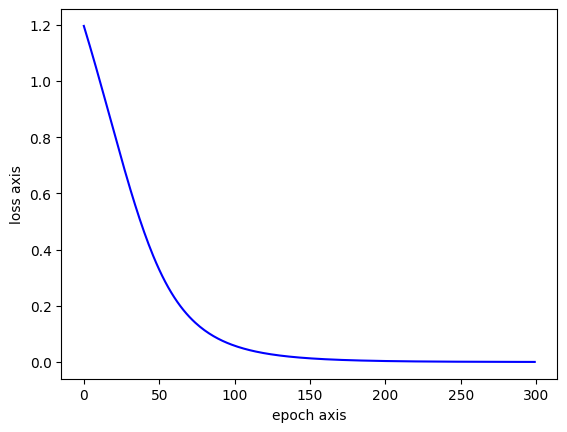

In [11]:
# 设置参数和输入
W_xh = torch.tensor([
    [0.1, 0.2],
    [-0.3, 0.4],
    [0.2, -0.1]])  # 形状 3x2

W_hh = torch.tensor([
    [0.5, -0.1, 0.1],
    [0.1, 0.3, -0.2],
    [-0.2, 0.4, 0.1]])  # 形状 3x3

x_0 = torch.tensor([[0.5, -0.2]])  # 形状 1x2
x_1 = torch.tensor([[0.1, 0.3]])  # 形状 1x2
h_target = torch.tensor([[0.5, -0.5, 0.5]])  # 形状 1x3

rnn_model = SimpleRNN(W_xh, W_hh, x_0, x_1)

criterion = nn.MSELoss()
optimizer = optim.SGD(rnn_model.parameters(), lr=0.01)

epochs = 300
losses = []

for epoch in range(epochs):
  h_1 = rnn_model(x_0, x_1)

  loss = criterion(h_1, h_target)
  losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if epoch%10 == 0:
    print(f"epoch: {epoch + 1}",
      f"loss: {loss.item():.4f}",
      f"h_1: {h_1}")

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.show()

In [11]:
#前向传播
def forward(W_xh, W_hh, x_0, x_1):
  h_int = torch.zeros(1, 3)
  z_0 = torch.matmul(x_0, W_xh.t()) + torch.matmul(h_int, W_hh.t()) #shape (1,3)
  h_0 = torch.tanh(z_0)

  z_1 = torch.matmul(x_1, W_xh.t()) + torch.matmul(h_0, W_hh.t()) #shape (1,3)
  h_1 = torch.tanh(z_1)
  return h_1

In [4]:
#计算损失函数loss
def compute_loss(h_1, h_target):
  loss = (h_1 - h_target)**2 /2
  return loss

epoch: 1 loss: 0.3752 h_1: tensor([[ 0.1091, -0.0007, -0.0902]], grad_fn=<TanhBackward0>)
epoch: 101 loss: 0.2571 h_1: tensor([[ 0.1770, -0.0918,  0.0069]], grad_fn=<TanhBackward0>)
epoch: 201 loss: 0.1598 h_1: tensor([[ 0.2472, -0.1895,  0.1009]], grad_fn=<TanhBackward0>)
epoch: 301 loss: 0.0876 h_1: tensor([[ 0.3146, -0.2819,  0.1945]], grad_fn=<TanhBackward0>)
epoch: 401 loss: 0.0435 h_1: tensor([[ 0.3710, -0.3559,  0.2774]], grad_fn=<TanhBackward0>)
epoch: 501 loss: 0.0204 h_1: tensor([[ 0.4129, -0.4083,  0.3423]], grad_fn=<TanhBackward0>)
epoch: 601 loss: 0.0094 h_1: tensor([[ 0.4421, -0.4430,  0.3892]], grad_fn=<TanhBackward0>)
epoch: 701 loss: 0.0044 h_1: tensor([[ 0.4617, -0.4652,  0.4221]], grad_fn=<TanhBackward0>)
epoch: 801 loss: 0.0021 h_1: tensor([[ 0.4747, -0.4792,  0.4449]], grad_fn=<TanhBackward0>)
epoch: 901 loss: 0.0010 h_1: tensor([[ 0.4833, -0.4880,  0.4607]], grad_fn=<TanhBackward0>)


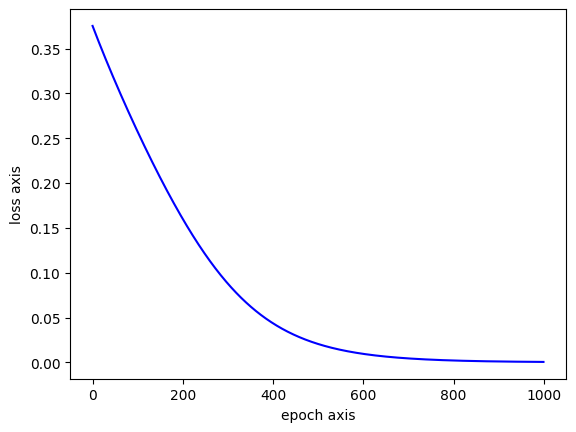

In [13]:
# 设置参数和输入
W_xh = torch.tensor([
    [0.1, 0.2],
    [-0.3, 0.4],
    [0.2, -0.1]],requires_grad=True)  # 形状 3x2

W_hh = torch.tensor([
    [0.5, -0.1, 0.1],
    [0.1, 0.3, -0.2],
    [-0.2, 0.4, 0.1]],requires_grad=True)  # 形状 3x3

x_0 = torch.tensor([[0.5, -0.2]])  # 形状 1x2
x_1 = torch.tensor([[0.1, 0.3]])  # 形状 1x2
h_target = torch.tensor([[0.5, -0.5, 0.5]])  # 形状 1x3

epochs = 1000
losses = []

learning_rate = 0.01

for epoch in range(epochs):
  h_1 = forward(W_xh, W_hh, x_0, x_1)

  loss = compute_loss(h_1, h_target).sum()
  losses.append(loss.item())

  if W_xh.grad is not None:
    W_xh.grad.zero_()
    W_hh.grad.zero_()

  loss.backward()

  with torch.no_grad():
    W_xh -= learning_rate * W_xh.grad
    W_hh -= learning_rate * W_hh.grad

  if epoch%100 == 0:
    print(f"epoch: {epoch + 1}",
      f"loss: {loss.item():.4f}",
      f"h_1: {h_1}")

plt.plot(range(epochs), losses, "blue")
plt.xlabel("epoch axis")
plt.ylabel("loss axis")
plt.show()